# Phase 2D: geometric reconfiguration-motif diagnostics

## Purpose and scope

This notebook tests whether three already-motivated defensive reorganizations have distinguishable **geometric motifs** in Metrica Sample Game 1. Motifs are descriptive patterns that may overlap. They are not tactical states, inferred responsibilities, causal mechanisms, quality judgments, or classes.

The exact seven Phase 2C windows, focal players, opponent pairs, and local defender selections are reused. No examples or pairings are added after inspection.

Primary summaries use raw 105 × 68 m geometry: trajectories, net displacement, path length, relative x/y paths, and pairwise distances. No derivatives are needed for the motif comparison, so 5/7/9-frame derivative smoothing does not determine the findings. Ball-relative context remains visible and is not interpreted as opponent-specific response.

## Motif signatures fixed before cross-case inspection

| Motif | Expected geometric signature | What would falsify or complicate it |
|---|---|---|
| Coordinated collective translation | Many defenders move substantially in absolute coordinates; centroid also moves substantially; displacement directions are broadly aligned; internal defender–defender geometry changes less or more slowly relative to the translation | Large opposing defender directions, large focal collective-relative motion, or internal reorganization comparable to the shared translation. Internal relationships need not be rigid. |
| Focal excursion | One focal defender moves substantially relative to the leave-one-out centroid and/or fixed local teammates; surrounding local geometry changes less or differently; opponent-relative change may or may not accompany it | Focal motion is mostly explained by centroid translation, or the local group changes similarly enough that no focal distinction remains. |
| Local compression | Multiple already-selected local defender pairs reduce distance or converge spatially; centroid motion may be small or large | Pairwise directions are mixed, only one pair contracts, or the appearance depends on freely changing the selected neighborhood. Compression does not imply success, engagement, or threat control. |

No numerical cutoff defines any motif. Transparent summaries provide evidence for or against the pre-written signatures.

In [1]:
from pathlib import Path
import hashlib,itertools
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

ROOT=Path.cwd().resolve()
if ROOT.name=='notebooks': ROOT=ROOT.parent
DATA=ROOT/'data'/'metrica_sample_game_1'
HOME_PATH=DATA/'Sample_Game_1_RawTrackingData_Home_Team.csv'; AWAY_PATH=DATA/'Sample_Game_1_RawTrackingData_Away_Team.csv'; EVENT_PATH=DATA/'Sample_Game_1_RawEventsData.csv'
LENGTH,WIDTH=105.,68.
def sha256(path):
    h=hashlib.sha256()
    with path.open('rb') as f:
        for block in iter(lambda:f.read(1024*1024),b''): h.update(block)
    return h.hexdigest()
display(pd.DataFrame({'file':[p.name for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)],'sha256':[sha256(p) for p in (HOME_PATH,AWAY_PATH,EVENT_PATH)]}))

,file,sha256
0,Sample_Game_1_RawTrackingData_Home_Team.csv,0a3d0eff7785950379c587d3597b86a2d91c2492281b46...
1,Sample_Game_1_RawTrackingData_Away_Team.csv,0a3df68a92af0290ede472e62de3b6489ddee29223da09...
2,Sample_Game_1_RawEventsData.csv,097dda6345e17390dca095331458fd00e47960c480c76f...


In [2]:
def load_tracking(path,team):
    h=pd.read_csv(path,header=None,nrows=3); ids=[str(int(float(v))) for v in h.iloc[1,3:-2:2] if pd.notna(v)]
    cols=['Period','Frame','Time [s]']
    for p in ids: cols += [f'{team}_{p}_x',f'{team}_{p}_y']
    cols += [f'{team}_ball_x',f'{team}_ball_y']
    return pd.read_csv(path,skiprows=3,names=cols),ids
home,hp=load_tracking(HOME_PATH,'Home'); away,ap=load_tracking(AWAY_PATH,'Away'); events=pd.read_csv(EVENT_PATH)
tracking={'Home':home,'Away':away}; players={'Home':hp,'Away':ap}; goalkeeper={'Home':'11','Away':'25'}
print({'Home':home.shape,'Away':away.shape,'events':events.shape})

{'Home': (145006, 33), 'Away': (145006, 33), 'events': (1745, 14)}


## Fixed cases and relationships

In [3]:
CASES=[
 {'name':'coordinated collective movement','role':'canonical translation','period':1,'start':1888.0,'end':1896.0,'def_team':'Home','focal':'2','opp_team':'Away','opponent':None,'selected_defs':None},
 {'name':'apparent focal excursion','role':'canonical excursion','period':1,'start':590.0,'end':598.0,'def_team':'Home','focal':'2','opp_team':'Away','opponent':'23','selected_defs':None},
 {'name':'tackle / engagement','role':'adversarial','period':1,'start':550.76,'end':555.76,'def_team':'Away','focal':'16','opp_team':'Home','opponent':'9','selected_defs':None},
 {'name':'1230.12 interior compression','role':'canonical compression','period':1,'start':1228.12,'end':1232.12,'def_team':'Away','focal':'19','opp_team':'Home','opponent':'10','selected_defs':['19','20','21'],'anchor':1230.12},
 {'name':'accommodation / compression sequence','role':'adversarial overlap','period':1,'start':1229.28,'end':1234.28,'def_team':'Away','focal':'19','opp_team':'Home','opponent':'10','selected_defs':['19','20','21'],'anchor':1232.28},
 {'name':'collective-translation contrast','role':'adversarial overlap','period':2,'start':3679.88,'end':3684.88,'def_team':'Home','focal':'8','opp_team':'Away','opponent':'15','selected_defs':None,'anchor':3682.88},
 {'name':'4197.04 heterogeneous negative','role':'negative','period':2,'start':4195.04,'end':4199.04,'def_team':'Away','focal':'16','opp_team':'Home','opponent':'10','selected_defs':['16','18','21'],'anchor':4197.04},
]
display(pd.DataFrame(CASES)[['name','role','period','start','end','def_team','focal','opp_team','opponent']])

,name,role,period,start,end,def_team,focal,opp_team,opponent
0,coordinated collective movement,canonical translation,1,1888.00,1896.00,Home,2,Away,None
1,apparent focal excursion,canonical excursion,1,590.00,598.00,Home,2,Away,23
2,tackle / engagement,adversarial,1,550.76,555.76,Away,16,Home,9
3,1230.12 interior compression,canonical compression,1,1228.12,1232.12,Away,19,Home,10
4,accommodation / compression sequence,adversarial overlap,1,1229.28,1234.28,Away,19,Home,10
5,collective-translation contrast,adversarial overlap,2,3679.88,3684.88,Home,8,Away,15
6,4197.04 heterogeneous negative,negative,2,4195.04,4199.04,Away,16,Home,10


In [4]:
def case_window(case):
    d=tracking[case['def_team']]; o=tracking[case['opp_team']]
    w=d[(d.Period==case['period'])&d['Time [s]'].between(case['start'],case['end'])].copy()
    cols=['Frame']+[f"{case['opp_team']}_{p}_{a}" for p in players[case['opp_team']] for a in ('x','y')]
    return w.merge(o[cols],on='Frame',validate='one_to_one')
def outfield(case): return [p for p in players[case['def_team']] if p!=goalkeeper[case['def_team']]]
def xy(r,team,p): return np.array([r[f'{team}_{p}_x']*LENGTH,r[f'{team}_{p}_y']*WIDTH],float)
def nearest_ids(case,w,count=3):
    if case['selected_defs']: return case['selected_defs']
    r=w.iloc[0]; f=xy(r,case['def_team'],case['focal']); vals=[]
    for p in outfield(case):
        if p==case['focal']: continue
        q=xy(r,case['def_team'],p)
        if np.isfinite(q).all(): vals.append((np.linalg.norm(q-f),p))
    return [case['focal']]+[p for _,p in sorted(vals)[:count-1]]
def add_base(case):
    w=case_window(case); dt=case['def_team']; ids=outfield(case); refs=[p for p in ids if p!=case['focal']]
    w['centroid_x_m']=w[[f'{dt}_{p}_x' for p in ids]].mean(axis=1)*LENGTH; w['centroid_y_m']=w[[f'{dt}_{p}_y' for p in ids]].mean(axis=1)*WIDTH
    w['loo_x_m']=w[[f'{dt}_{p}_x' for p in refs]].mean(axis=1)*LENGTH; w['loo_y_m']=w[[f'{dt}_{p}_y' for p in refs]].mean(axis=1)*WIDTH
    w['focal_loo_x_m']=w[f'{dt}_{case["focal"]}_x']*LENGTH-w.loo_x_m; w['focal_loo_y_m']=w[f'{dt}_{case["focal"]}_y']*WIDTH-w.loo_y_m
    w['plot_t']=w['Time [s]']-case['start']; return w
def path_length(x,y): return np.nansum(np.hypot(np.diff(np.asarray(x,float)),np.diff(np.asarray(y,float))))
for case in CASES:
    w=add_base(case); case['display_defs']=nearest_ids(case,w); print(case['name'],case['display_defs'])

coordinated collective movement ['2', '3', '7']
apparent focal excursion ['2', '3', '1']
tackle / engagement ['16', '17', '15']
1230.12 interior compression ['19', '20', '21']
accommodation / compression sequence ['19', '20', '21']
collective-translation contrast ['8', '10', '5']
4197.04 heterogeneous negative ['16', '18', '21']


## Canonical comparison: translation vs excursion vs compression

The top row shows raw pitch trajectories, the defensive centroid, and the already-fixed local defenders. The middle row shows collective displacement and focal leave-one-out-centroid-relative components separately. The bottom row shows changes in selected defender-pair distances. These are visual motifs, not assigned states.

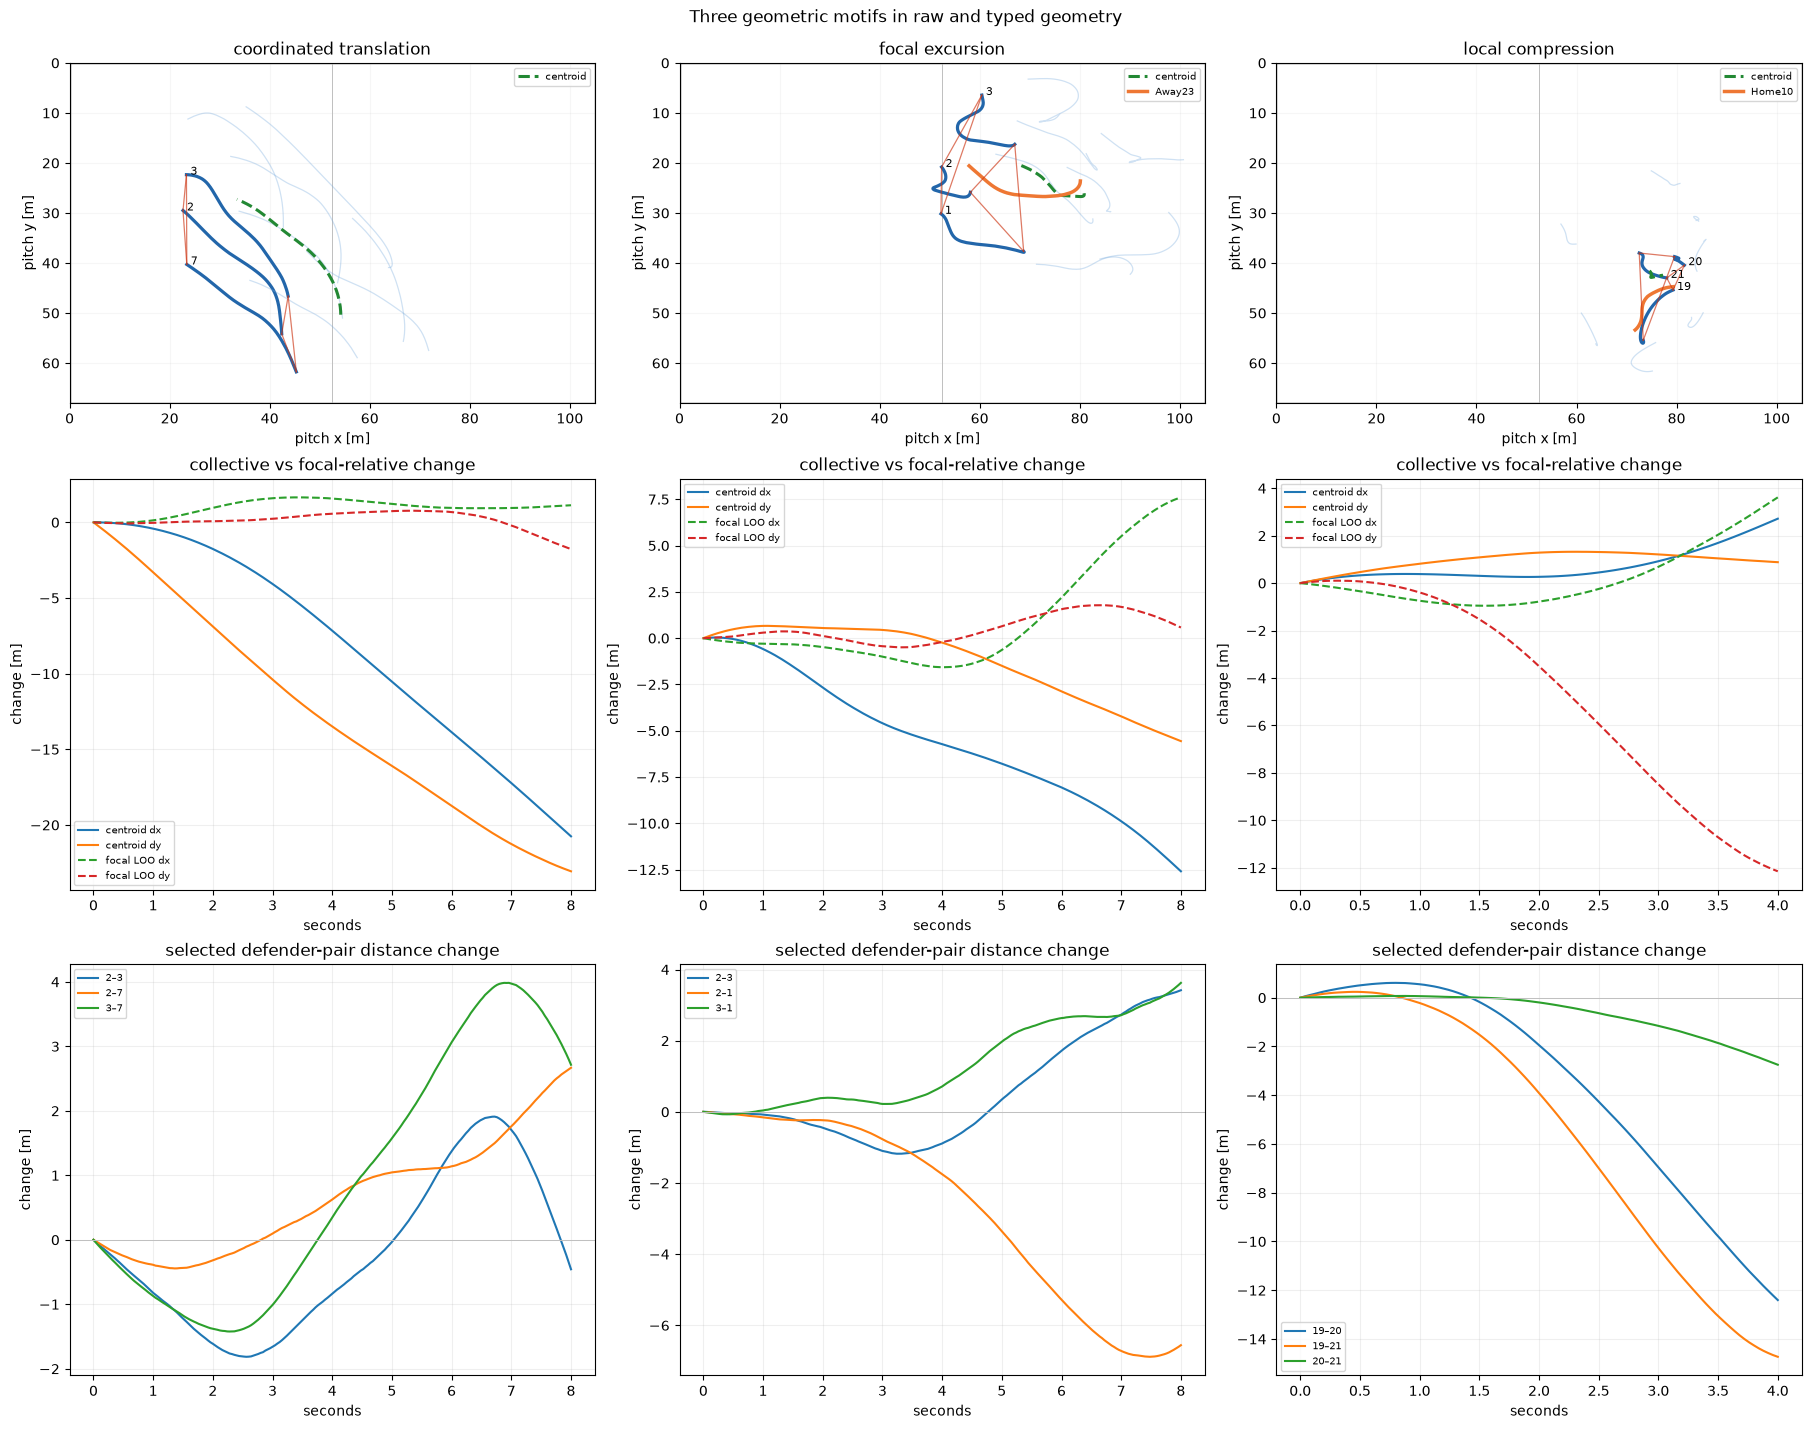

In [5]:
def pitch(ax):
    ax.plot([0,LENGTH,LENGTH,0,0],[0,0,WIDTH,WIDTH,0],c='0.35',lw=1); ax.axvline(LENGTH/2,c='0.75',lw=.7)
    ax.set(xlim=(0,LENGTH),ylim=(WIDTH,0),aspect='equal',xlabel='pitch x [m]',ylabel='pitch y [m]'); ax.grid(alpha=.1)
canon=[next(x for x in CASES if x['role']==r) for r in ['canonical translation','canonical excursion','canonical compression']]
fig,axes=plt.subplots(3,3,figsize=(18,14),constrained_layout=True)
titles=['coordinated translation','focal excursion','local compression']
for col,(case,title) in enumerate(zip(canon,titles)):
    w=add_base(case); dt,ot=case['def_team'],case['opp_team']; defs=case['display_defs']; t=w.plot_t
    ax=axes[0,col]; pitch(ax)
    for p in outfield(case):
        x=w[f'{dt}_{p}_x']*LENGTH; y=w[f'{dt}_{p}_y']*WIDTH; emph=p in defs
        ax.plot(x,y,c='#2266aa' if emph else '#77aadd',lw=2.3 if emph else .9,alpha=1 if emph else .35)
        if emph: ax.text(x.iloc[-1],y.iloc[-1],f' {p}',fontsize=8)
    ax.plot(w.centroid_x_m,w.centroid_y_m,c='#228833',ls='--',lw=2.2,label='centroid')
    if case['opponent']:
        ax.plot(w[f'{ot}_{case["opponent"]}_x']*LENGTH,w[f'{ot}_{case["opponent"]}_y']*WIDTH,c='#ee7733',lw=2.5,label=f'{ot}{case["opponent"]}')
    for p,q in itertools.combinations(defs,2):
        for idx in [w.index[0],w.index[-1]]:
            a,b=xy(w.loc[idx],dt,p),xy(w.loc[idx],dt,q); ax.plot([a[0],b[0]],[a[1],b[1]],c='#cc3311',lw=.9,alpha=.65)
    ax.set_title(title); ax.legend(fontsize=7)
    ax=axes[1,col]
    ax.plot(t,w.centroid_x_m-w.centroid_x_m.iloc[0],label='centroid dx'); ax.plot(t,w.centroid_y_m-w.centroid_y_m.iloc[0],label='centroid dy')
    ax.plot(t,w.focal_loo_x_m-w.focal_loo_x_m.iloc[0],ls='--',label='focal LOO dx'); ax.plot(t,w.focal_loo_y_m-w.focal_loo_y_m.iloc[0],ls='--',label='focal LOO dy')
    ax.set(title='collective vs focal-relative change',ylabel='change [m]',xlabel='seconds'); ax.grid(alpha=.2); ax.legend(fontsize=7)
    ax=axes[2,col]
    for p,q in itertools.combinations(defs,2):
        d=np.hypot((w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{dt}_{q}_y'])*WIDTH); ax.plot(t,d-d.iloc[0],label=f'{p}–{q}')
    ax.set(title='selected defender-pair distance change',ylabel='change [m]',xlabel='seconds'); ax.axhline(0,c='0.75',lw=.7); ax.grid(alpha=.2); ax.legend(fontsize=7)
fig.suptitle('Three geometric motifs in raw and typed geometry',y=1.01); plt.show()

## Transparent descriptive summaries

`direction cosine` compares each outfield defender's start-to-end displacement direction with the centroid displacement direction: +1 means parallel, 0 orthogonal, and −1 opposite. The mean is reported only as a descriptive alignment summary, not a motif score. Path lengths retain curved movement that endpoint displacement can miss.

In [6]:
def summary(case):
    w=add_base(case); dt,ot=case['def_team'],case['opp_team']; ids=outfield(case); defs=case['display_defs']; s,e=w.iloc[0],w.iloc[-1]
    centroid_vec=np.array([w.centroid_x_m.iloc[-1]-w.centroid_x_m.iloc[0],w.centroid_y_m.iloc[-1]-w.centroid_y_m.iloc[0]])
    disps=[]; cosines=[]
    for p in ids:
        v=xy(e,dt,p)-xy(s,dt,p)
        if np.isfinite(v).all():
            disps.append(np.linalg.norm(v))
            if np.linalg.norm(v)>1e-9 and np.linalg.norm(centroid_vec)>1e-9: cosines.append(np.dot(v,centroid_vec)/(np.linalg.norm(v)*np.linalg.norm(centroid_vec)))
    focal_raw=np.array([w[f'{dt}_{case["focal"]}_x']*LENGTH,w[f'{dt}_{case["focal"]}_y']*WIDTH]).T
    focal_loo=np.array([w.focal_loo_x_m,w.focal_loo_y_m]).T
    pair_changes=[]
    for p,q in itertools.combinations(defs,2):
        d=np.hypot((w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{dt}_{q}_y'])*WIDTH); pair_changes.append(float(d.iloc[-1]-d.iloc[0]))
    row={'case':case['name'],'centroid_net_m':np.linalg.norm(centroid_vec),'centroid_path_m':path_length(w.centroid_x_m,w.centroid_y_m),
         'outfield_median_net_m':np.nanmedian(disps),'outfield_max_net_m':np.nanmax(disps),'mean_direction_cosine':np.nanmean(cosines),
         'focal_raw_net_m':np.linalg.norm(focal_raw[-1]-focal_raw[0]),'focal_raw_path_m':path_length(focal_raw[:,0],focal_raw[:,1]),
         'focal_LOO_net_m':np.linalg.norm(focal_loo[-1]-focal_loo[0]),'focal_LOO_path_m':path_length(focal_loo[:,0],focal_loo[:,1]),
         'selected_DD_changes_m':', '.join(f'{v:+.2f}' for v in pair_changes)}
    if case['opponent']:
        d=np.hypot((w[f'{dt}_{case["focal"]}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,(w[f'{dt}_{case["focal"]}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH)
        row['focal_opponent_change_m']=d.iloc[-1]-d.iloc[0]; row['focal_opponent_range_m']=d.max()-d.min()
    else: row['focal_opponent_change_m']=np.nan; row['focal_opponent_range_m']=np.nan
    bx=w[f'{dt}_ball_x']*LENGTH; by=w[f'{dt}_ball_y']*WIDTH
    row['focal_ball_x_span_m']=(w[f'{dt}_{case["focal"]}_x']*LENGTH-bx).max()-(w[f'{dt}_{case["focal"]}_x']*LENGTH-bx).min()
    row['focal_ball_y_span_m']=(w[f'{dt}_{case["focal"]}_y']*WIDTH-by).max()-(w[f'{dt}_{case["focal"]}_y']*WIDTH-by).min()
    return row
summaries=pd.DataFrame([summary(x) for x in CASES]).set_index('case')
display(summaries.round(3))

,centroid_net_m,centroid_path_m,outfield_median_net_m,outfield_max_net_m,mean_direction_cosine,focal_raw_net_m,focal_raw_path_m,focal_LOO_net_m,focal_LOO_path_m,selected_DD_changes_m,focal_opponent_change_m,focal_opponent_range_m,focal_ball_x_span_m,focal_ball_y_span_m
case,,,,,,,,,,,,,,
coordinated collective movement,31.021,32.444,31.042,42.925,0.990,31.577,33.182,2.099,5.290,"-0.46, +2.67, +2.71",NaN,NaN,12.382,25.127
apparent focal excursion,13.763,15.275,15.927,23.291,0.910,7.645,14.218,7.625,12.392,"+3.42, -6.56, +3.62",-16.597,16.821,34.621,16.759
tackle / engagement,18.993,19.080,23.597,29.520,0.976,29.509,30.323,13.806,16.259,"+5.29, -11.71, -7.44",-9.792,11.106,4.155,13.281
1230.12 interior compression,2.856,3.926,5.948,11.690,0.621,11.690,14.114,12.675,14.118,"-12.40, -14.73, -2.75",-1.963,4.411,9.282,12.508
accommodation / compression sequence,3.786,5.481,5.994,13.144,0.462,13.144,18.698,11.630,17.110,"-15.35, -12.74, -4.83",0.037,4.978,8.433,5.282
collective-translation contrast,19.314,19.515,17.999,31.431,0.991,30.315,30.431,12.247,12.825,"+8.85, -2.99, -3.49",-7.485,8.101,10.829,13.388
4197.04 heterogeneous negative,4.353,5.381,4.648,11.978,0.813,4.617,5.616,0.524,1.143,"+5.12, -5.56, +5.29",1.237,1.621,12.536,15.400


## Adversarial case views

Each fixed case is shown with the same four views. The purpose is to preserve overlaps and failures rather than force one motif label.

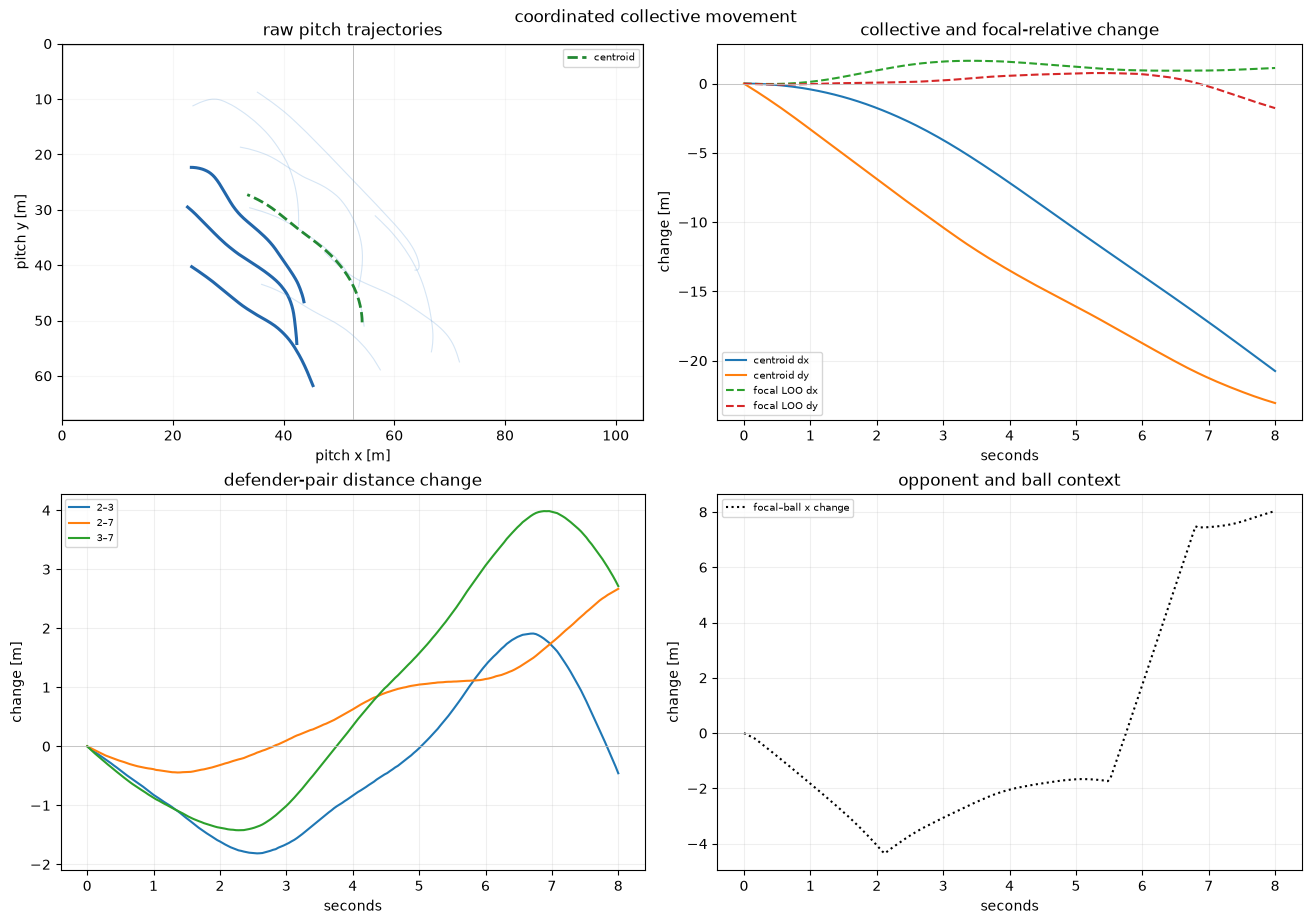

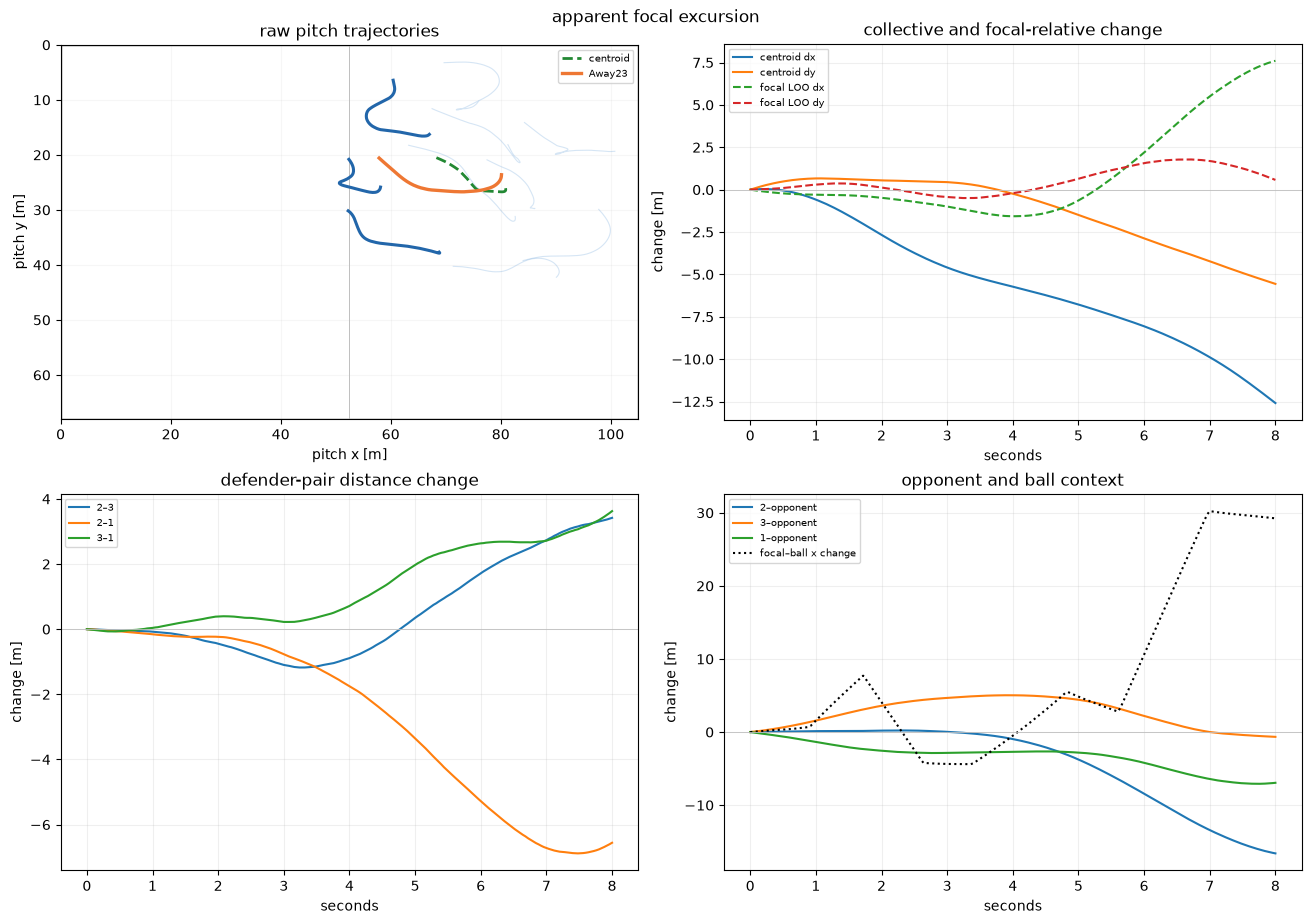

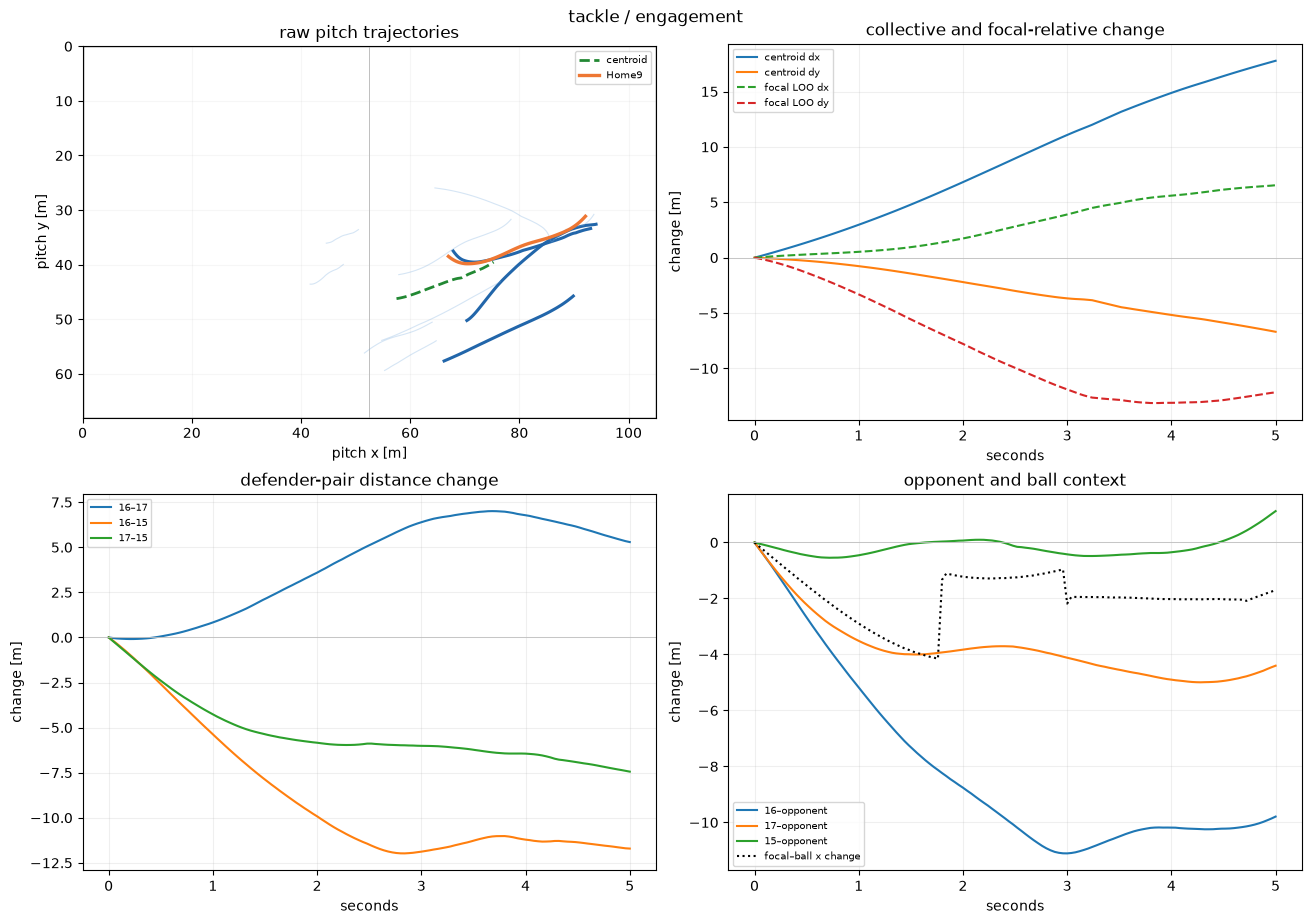

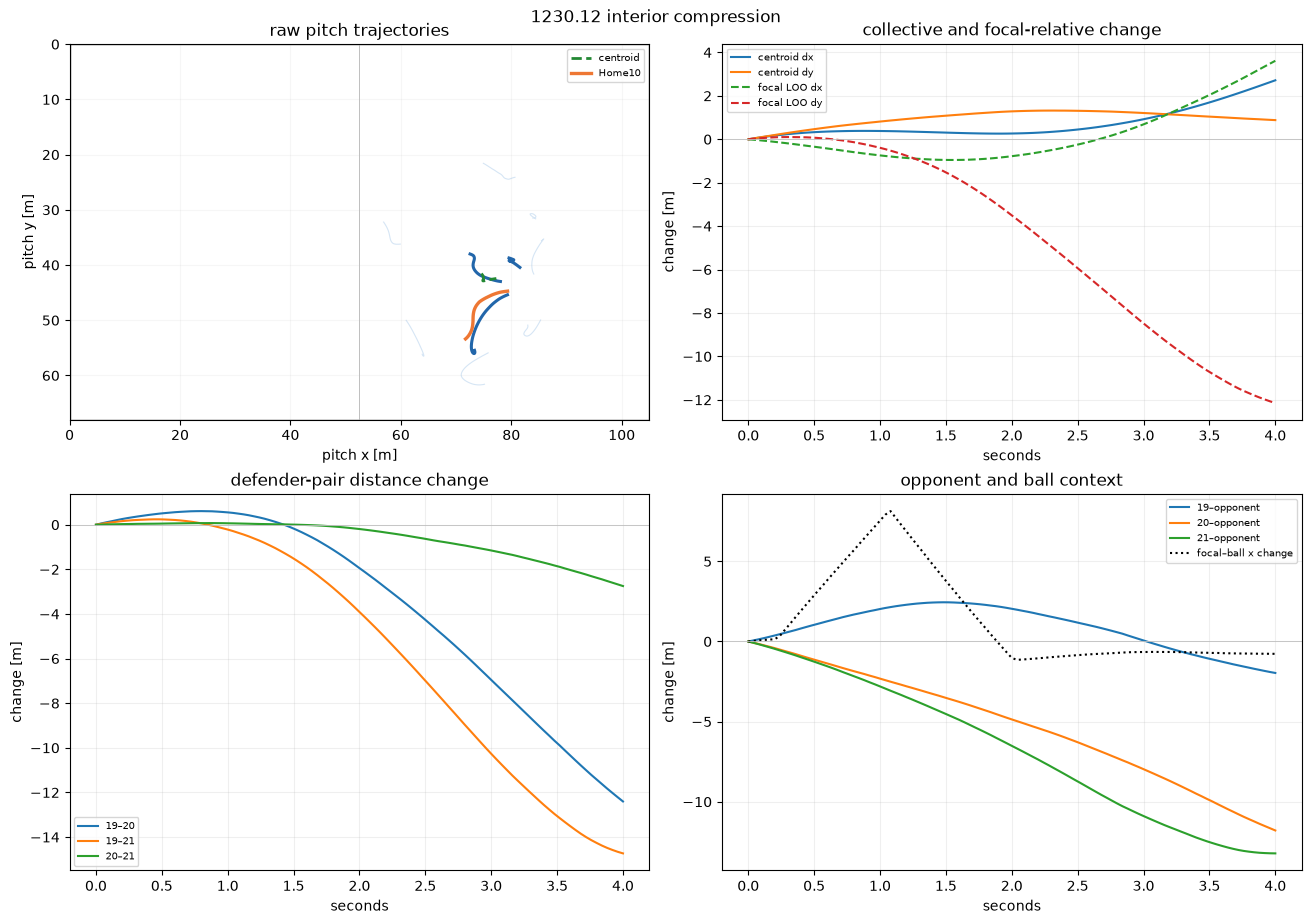

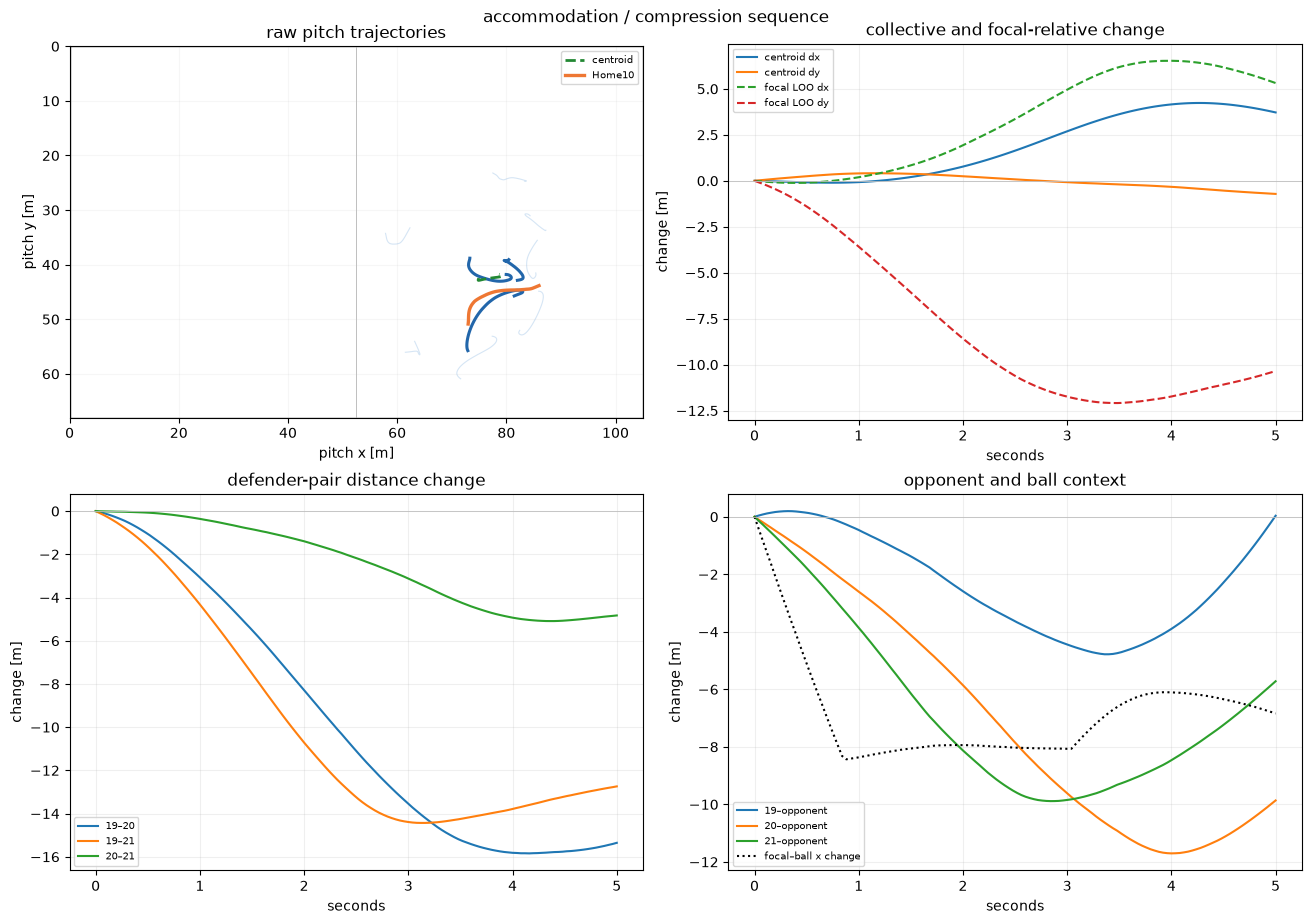

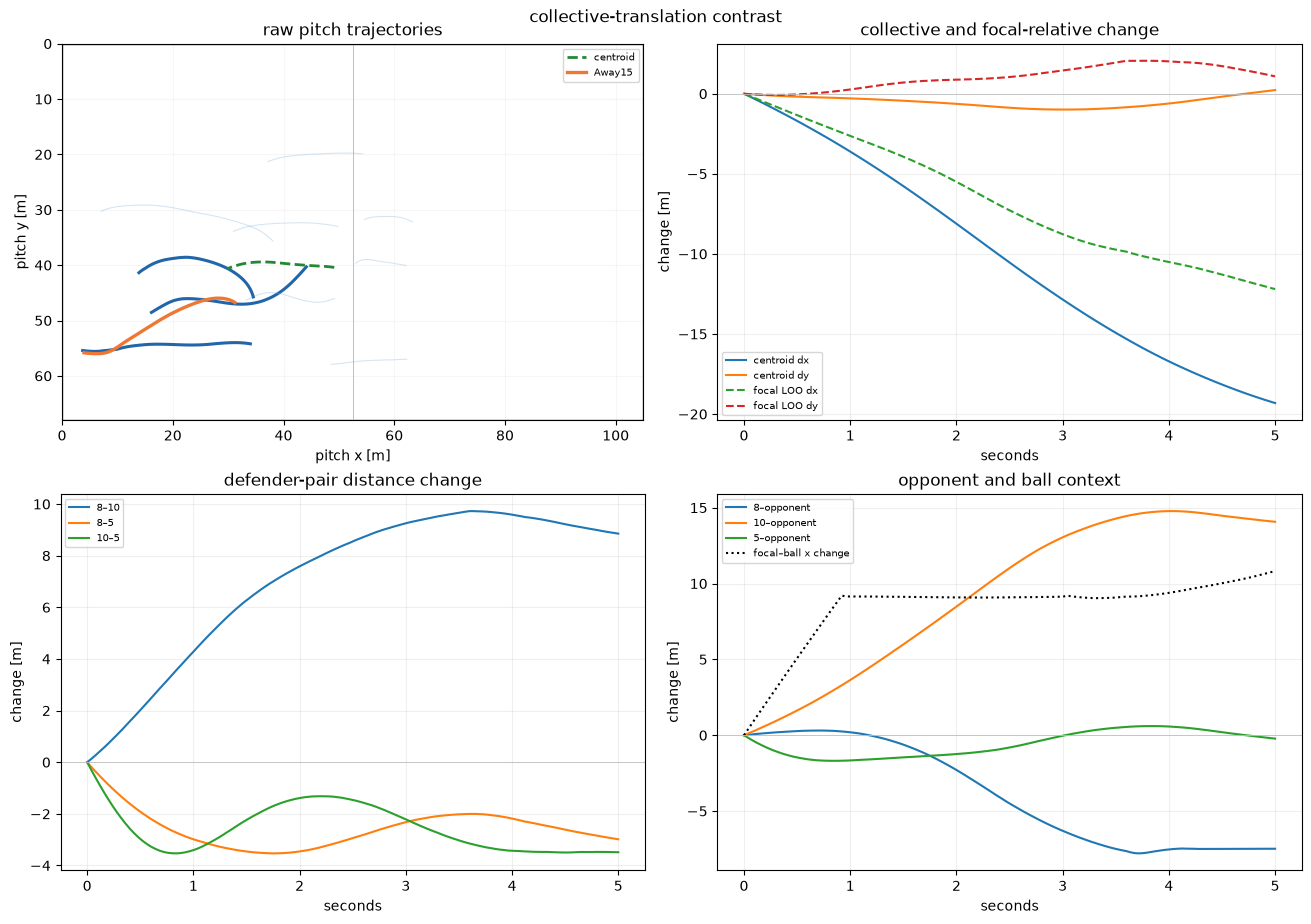

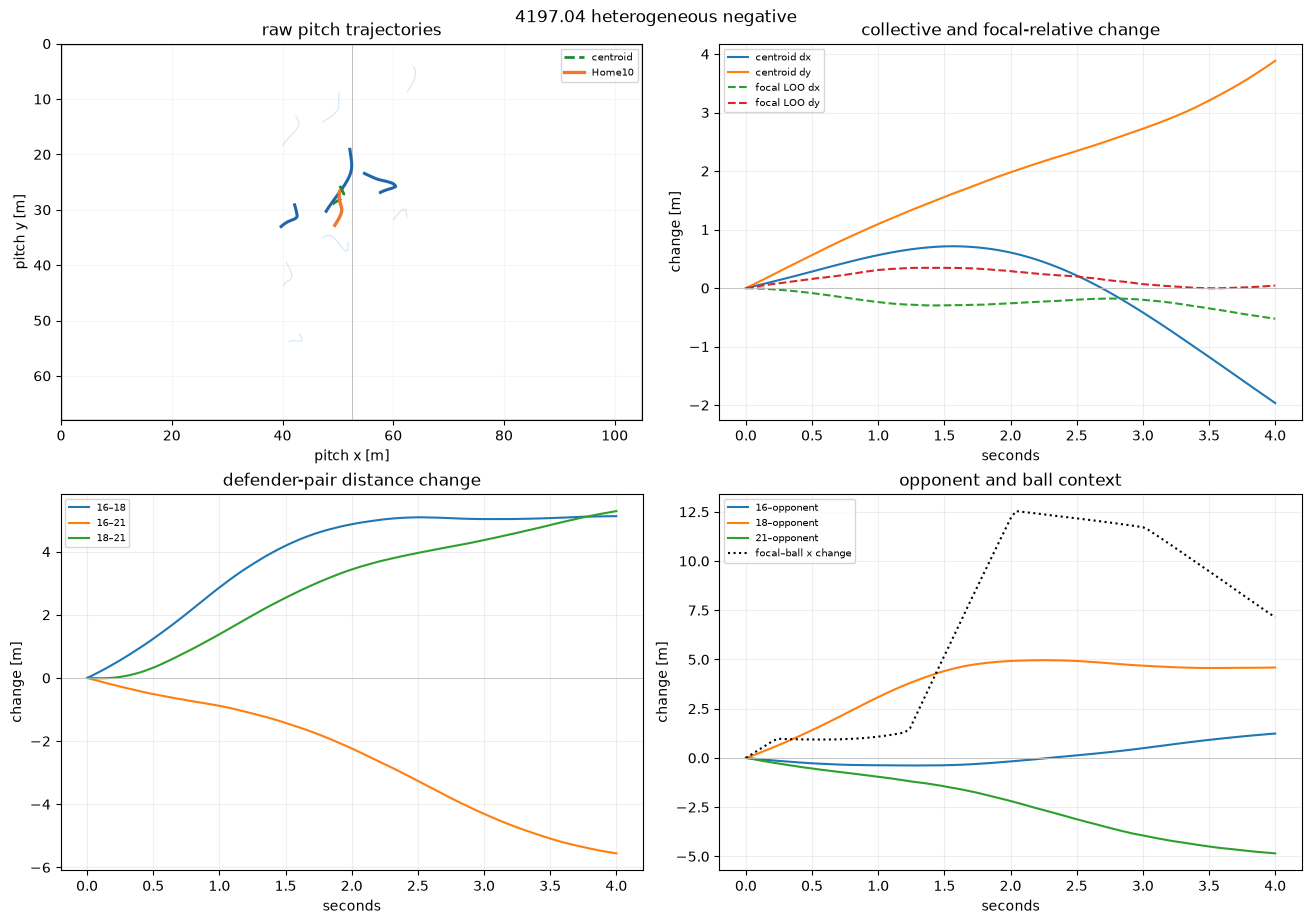

In [7]:
def case_panels(case):
    w=add_base(case); dt,ot=case['def_team'],case['opp_team']; defs=case['display_defs']; t=w.plot_t
    fig,axes=plt.subplots(2,2,figsize=(13,9),constrained_layout=True)
    ax=axes[0,0]; pitch(ax)
    for p in outfield(case):
        x=w[f'{dt}_{p}_x']*LENGTH; y=w[f'{dt}_{p}_y']*WIDTH; emph=p in defs; ax.plot(x,y,c='#2266aa' if emph else '#77aadd',lw=2.2 if emph else .8,alpha=1 if emph else .3)
    ax.plot(w.centroid_x_m,w.centroid_y_m,c='#228833',ls='--',lw=2,label='centroid')
    if case['opponent']: ax.plot(w[f'{ot}_{case["opponent"]}_x']*LENGTH,w[f'{ot}_{case["opponent"]}_y']*WIDTH,c='#ee7733',lw=2.4,label=f'{ot}{case["opponent"]}')
    ax.set_title('raw pitch trajectories'); ax.legend(fontsize=7)
    ax=axes[0,1]; ax.plot(t,w.centroid_x_m-w.centroid_x_m.iloc[0],label='centroid dx'); ax.plot(t,w.centroid_y_m-w.centroid_y_m.iloc[0],label='centroid dy'); ax.plot(t,w.focal_loo_x_m-w.focal_loo_x_m.iloc[0],ls='--',label='focal LOO dx'); ax.plot(t,w.focal_loo_y_m-w.focal_loo_y_m.iloc[0],ls='--',label='focal LOO dy'); ax.set_title('collective and focal-relative change')
    ax=axes[1,0]
    for p,q in itertools.combinations(defs,2):
        d=np.hypot((w[f'{dt}_{p}_x']-w[f'{dt}_{q}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{dt}_{q}_y'])*WIDTH); ax.plot(t,d-d.iloc[0],label=f'{p}–{q}')
    ax.set_title('defender-pair distance change')
    ax=axes[1,1]
    if case['opponent']:
        for p in defs:
            d=np.hypot((w[f'{dt}_{p}_x']-w[f'{ot}_{case["opponent"]}_x'])*LENGTH,(w[f'{dt}_{p}_y']-w[f'{ot}_{case["opponent"]}_y'])*WIDTH); ax.plot(t,d-d.iloc[0],label=f'{p}–opponent')
    bx=w[f'{dt}_ball_x']*LENGTH; ax.plot(t,(w[f'{dt}_{case["focal"]}_x']*LENGTH-bx)-(w[f'{dt}_{case["focal"]}_x']*LENGTH-bx).iloc[0],c='black',ls=':',label='focal–ball x change')
    ax.set_title('opponent and ball context')
    for ax in axes.flat:
        if ax is not axes[0,0]: ax.axhline(0,c='0.75',lw=.6); ax.set(xlabel='seconds',ylabel='change [m]'); ax.grid(alpha=.2); ax.legend(fontsize=7)
    fig.suptitle(case['name'],y=1.01); plt.show()
for case in CASES: case_panels(case)

## Cross-case motif assessment

| Case | Coordinated translation | Focal excursion | Local compression | Complication / overlap |
|---|---|---|---|---|
| 1888–1896 coordinated movement | Descriptively supported: large centroid and outfield displacement with broadly aligned directions | Not the main signature: focal collective-relative change is smaller than shared movement | Not supported as a broad contraction pattern; selected internal distances are non-rigid and mixed over time | Translation is coherent only comparatively, not “structure preserved” |
| 590–598 apparent excursion | Partial shared translation is present | Descriptively supported: focal leave-one-out path/change is prominent and local pair directions differ | Not supported as broad local compression | Opponent distance and ball-relative change also occur; neither proves tracking/closing |
| 550.76–555.76 tackle/engagement | Partially supported | Partially supported | Partially supported | Translation, focal movement, opponent convergence, and local contraction overlap; no single motif is adequate |
| 1228.12–1232.12 interior case | Limited near-anchor translation | Focal Away19 has a distinct curved relation but is not the whole pattern | Descriptively supported across the fixed local trio | Compression coexists with opponent and secondary-opponent redistribution |
| 1229.28–1234.28 accommodation/compression | Partial translation | Partial focal deviation | Descriptively supported early, followed by expansion | Multiple motifs overlap within one continuous play |
| 3679.88–3684.88 translation contrast | Descriptively supported in a dominant pitch component | Partially supported | Partially supported late | Demonstrates translation + compression coexistence and explains the Phase 2C false positive |
| 4195.04–4199.04 negative | Partial centroid movement but directions are not uniformly coherent | Not clearly supported | Not supported: selected pair directions are mixed | Remains heterogeneous/no-clean-motif without changing relationships |

These are assessments of the pre-written geometric ideas, not sequence labels. A row may support several motifs or none.

## Falsification and conservative conclusions

- **Same generic movement under different words?** No in the canonical cases: translation emphasizes shared absolute/centroid motion, excursion emphasizes focal collective-relative motion, and compression emphasizes multi-pair contraction. However, the tackle and translation-contrast cases show that the signatures can overlap strongly.
- **Still distinguishable with centroid and ball shown?** Broadly yes for the canonical cases. Ball movement remains large in several windows and prevents tactical interpretation of opponent-relative change.
- **Unfalsifiable relationship selection?** This remains a major risk. The diagnostic avoids it by freezing Phase 2A selections. A future motif definition would require prospective, stable neighborhood rules; arbitrary pair choice would invalidate the vocabulary.
- **5/7/9 robustness?** Primary motif evidence uses raw geometry and no derivatives, so it is not altered by derivative smoothing. This does not solve relationship-selection or window-boundary sensitivity.
- **Negative case?** The 4197.04s case remains mixed/no-clean-motif with the unchanged trio.
- **Raw interpretability?** The canonical distinctions are visible in raw trajectories before derived summaries, though the adversarial overlaps require the typed views to describe precisely.

Motif assessments:

- **Coordinated collective translation: descriptively supported**, with the qualification that internal geometry is not rigid and no quality claim follows.
- **Focal excursion: descriptively supported**, but opponent and ball relationships remain alternative/contextual channels rather than inferred motives.
- **Local compression: descriptively supported**, including both low- and high-translation forms; it is not equivalent to success or engagement.

## Is a motif vocabulary more defensible than a universal detector?

For these fixed diagnostics, **yes, provisionally**: a small overlapping vocabulary preserves why geometry changed and accommodates translation + compression, excursion + opponent convergence, compression followed by expansion, and no-clean-motif cases. It is more faithful to the observed heterogeneity than the Phase 2C universal-episode attempt. This is not evidence that the vocabulary is complete, generalizable, or ready for automated classification.

**Defensive relational reallocation** is refined to mean temporal change that may be described through one or more overlapping, soccer-interpretable geometric motifs while retaining the underlying typed relationships. It is not itself a motif, state, class, score, or universal event. Pinning, handoff, accommodation, rotation, and exposure remain unresolved future possibilities rather than motifs added here.

No motif classifier, motif score, composite index, relational weights, gravity metric, attacker attribution, assignment inference, tactical-state model, HMM, clustering, network, ML, change-point optimization, causal inference, or dataset expansion is introduced. Phase 2D stops here.